In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

Saving marketing_campaign.csv to marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (2240, 29)

Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Missing Values:
ID                      0
Year_Birth   

In [5]:
df['Income'].fillna(df['Income'].median(), inplace=True)
print("Missing values after fix:", df.isnull().sum().sum())

Missing values after fix: 0


/tmp/ipykernel_28793/2156825483.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())
print("Missing values after fix:", df.isnull().sum().sum())

Missing values after fix: 0


In [7]:
df['Age'] = 2024 - df['Year_Birth']
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['TotalSpending'] = (df['MntWines'] + df['MntFruits'] +
                       df['MntMeatProducts'] + df['MntFishProducts'] +
                       df['MntSweetProducts'] + df['MntGoldProds'])
df['TotalPurchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                        df['NumStorePurchases'])

print("New columns added successfully!")
print(df[['Age', 'TotalChildren', 'TotalSpending', 'TotalPurchases']].head())

New columns added successfully!
   Age  TotalChildren  TotalSpending  TotalPurchases
0   67              0           1617              22
1   70              2             27               4
2   59              0            776              20
3   40              1             53               6
4   43              1            422              14


Part 2

In [ ]:
df['Age'].mean()

np.float64(55.19419642857143)

In [10]:
df['Education'].mode()[0]

'Graduation'

In [11]:
df['Marital_Status'].mode()[0]

'Married'

In [12]:
df['Income'].mean()

np.float64(52237.97544642857)

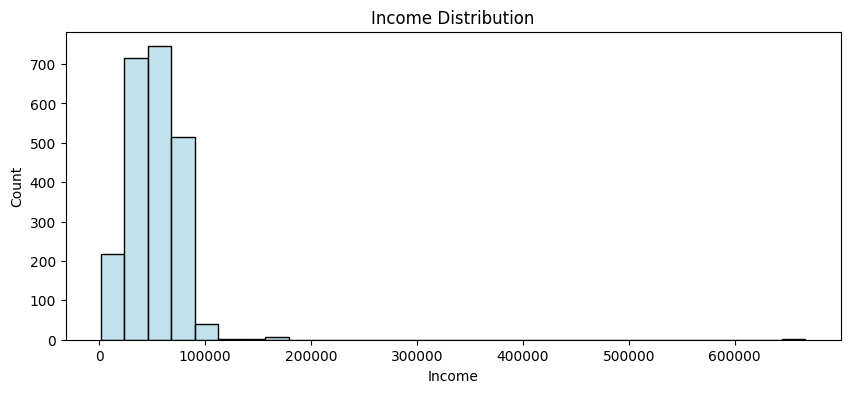

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Income'], bins=30, color='lightblue')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

Most customers earn between 20,000 and 80,000. The distribution is right-skewed due to a small number of high-income outliers reaching up to 666,666.



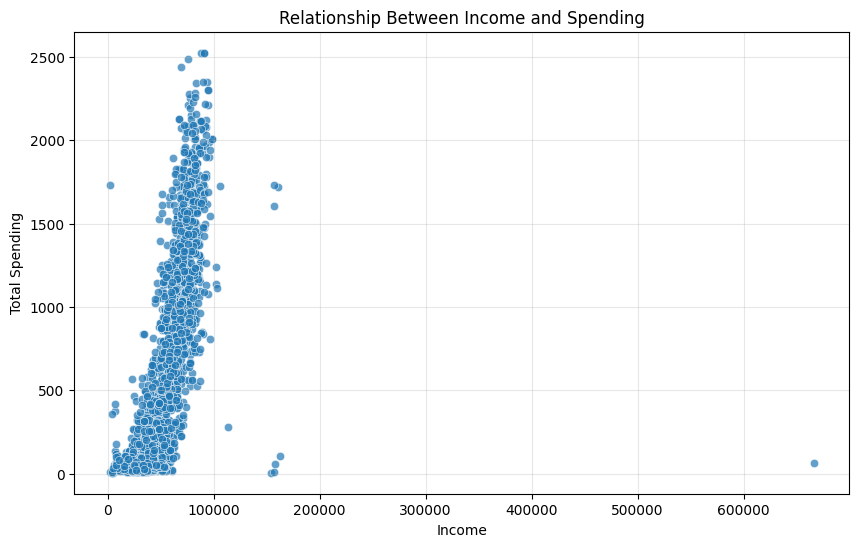

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='TotalSpending', alpha=0.7)
plt.title('Relationship Between Income and Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.grid(True, alpha=0.3)
plt.show()

There is a positive relationship between income and total spending. Customers with higher income tend to spend more.


In [15]:
product_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
category_totals = df[product_columns].sum().sort_values(ascending=False)
print(category_totals)

MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64


Highest: MntWines — 680,816
Lowest: MntFruits — 58,917

In [16]:
percentage = df['Response'].mean() * 100
print(f"Percentage of customers who accepted: {percentage:.2f}%")

Percentage of customers who accepted: 14.91%


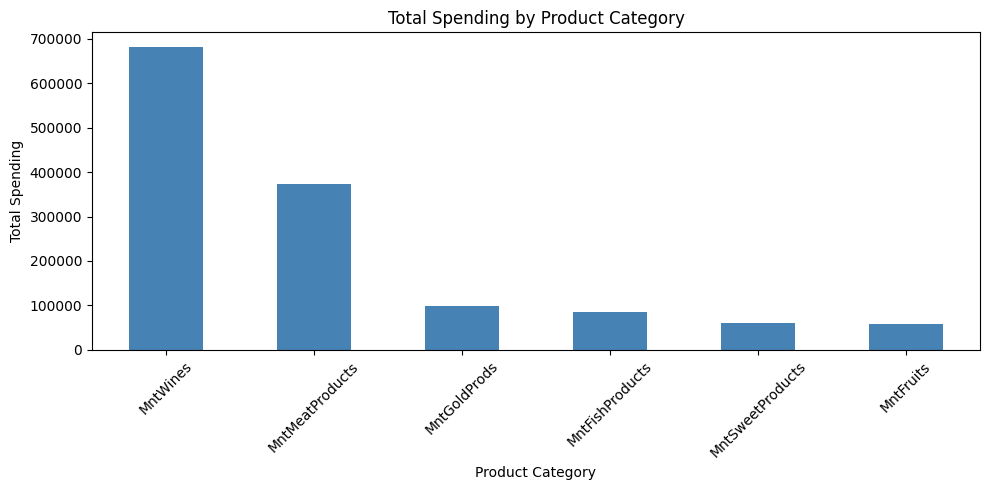

In [17]:
plt.figure(figsize=(10, 5))
category_totals.plot(kind='bar', color='steelblue')
plt.title('Total Spending by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Wines dominate spending by far, followed by Meat Products. Fruits and Sweets generate the lowest spending.



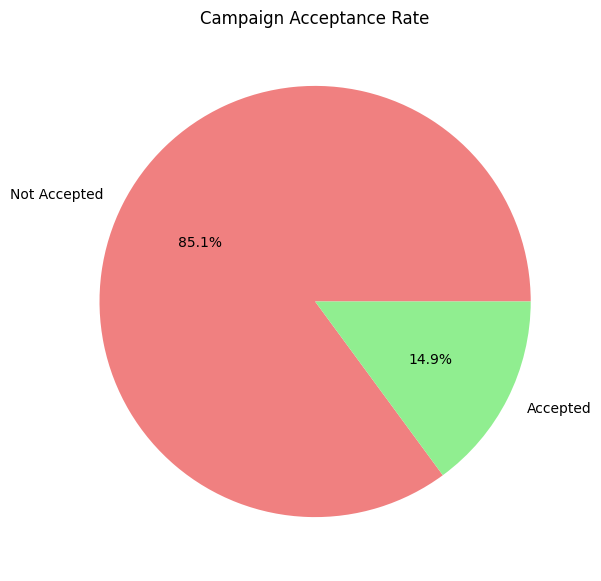

In [18]:
plt.figure(figsize=(7, 7))
df['Response'].value_counts().plot(kind='pie',
                                    labels=['Not Accepted', 'Accepted'],
                                    autopct='%1.1f%%',
                                    colors=['lightcoral', 'lightgreen'])
plt.title('Campaign Acceptance Rate')
plt.ylabel('')
plt.show()

Only 14.9% of customers accepted the campaign, while 85.1% did not. This indicates a class imbalance that must be considered in the classification model.



/tmp/ipykernel_28793/1147712316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Income', palette='Set2')


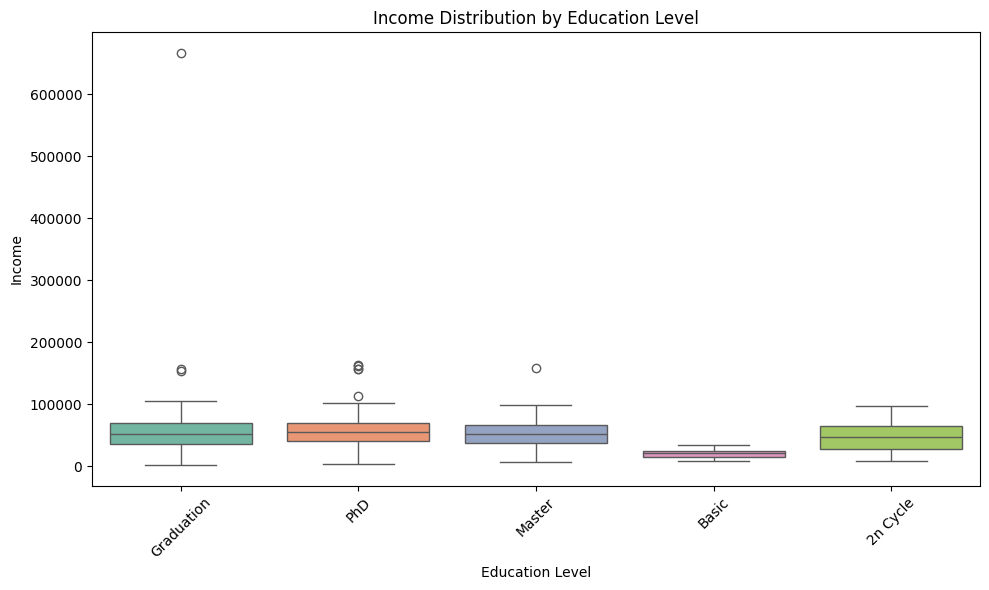

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education', y='Income', palette='Set2')
plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customers with Basic education have significantly lower income compared to other education levels. PhD and Master holders show similar income ranges with some high-income outliers.

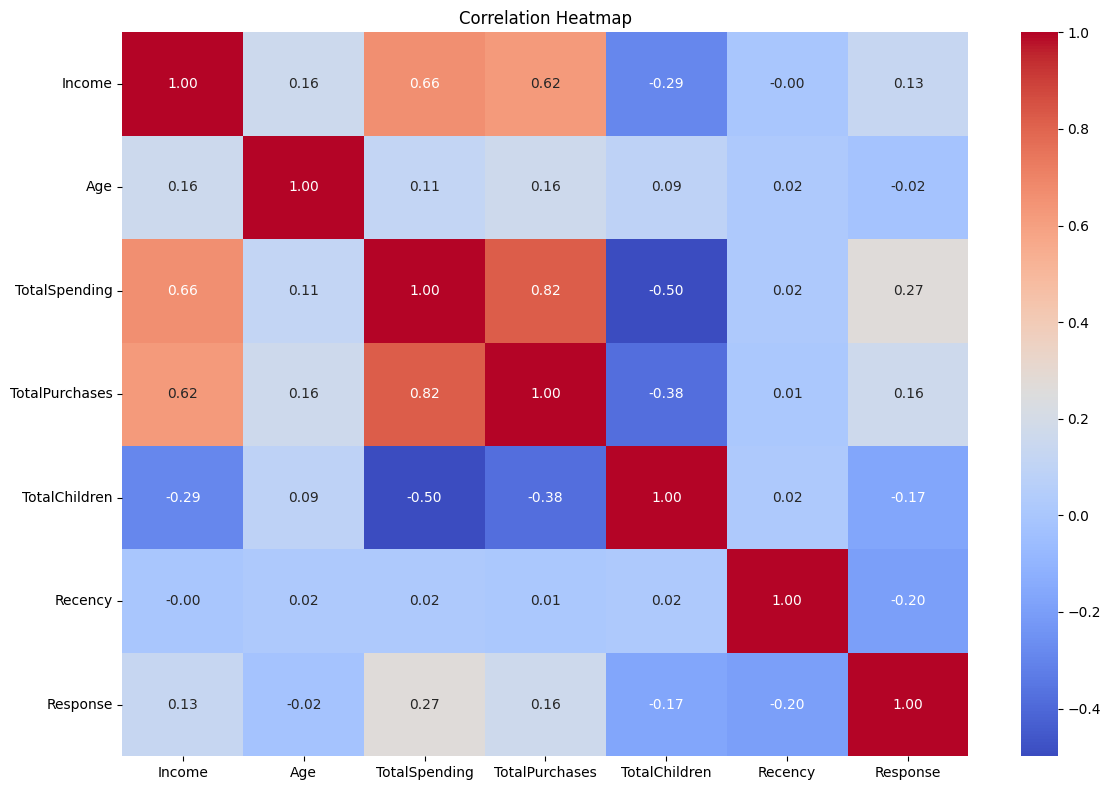

In [20]:
plt.figure(figsize=(12, 8))
numeric_cols = ['Income', 'Age', 'TotalSpending', 'TotalPurchases',
                'TotalChildren', 'Recency', 'Response']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Income and TotalSpending are strongly correlated. Customers with more children tend to spend less. Recency has little correlation with other variables.



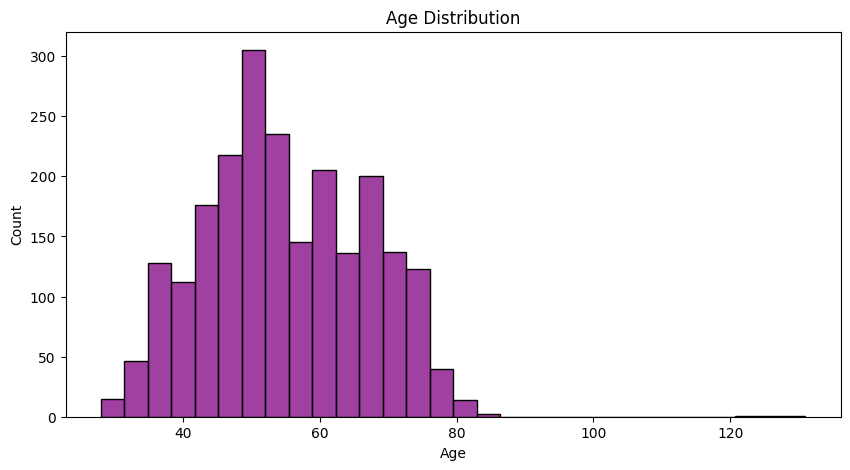

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, color='purple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Most customers are between 40 and 60 years old, with the peak around 50. Very few customers are above 80.

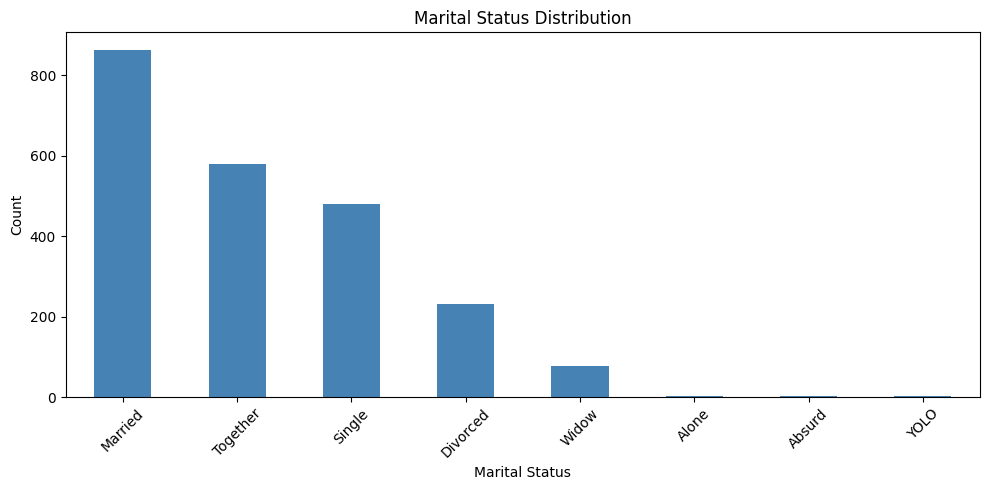

In [22]:
plt.figure(figsize=(10, 5))
df['Marital_Status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Married customers are the most common, followed by Together and Single. A small number of records contain invalid values like 'Absurd' and 'YOLO

/tmp/ipykernel_28793/2002530935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital_Status', y='TotalSpending', palette='Set3')


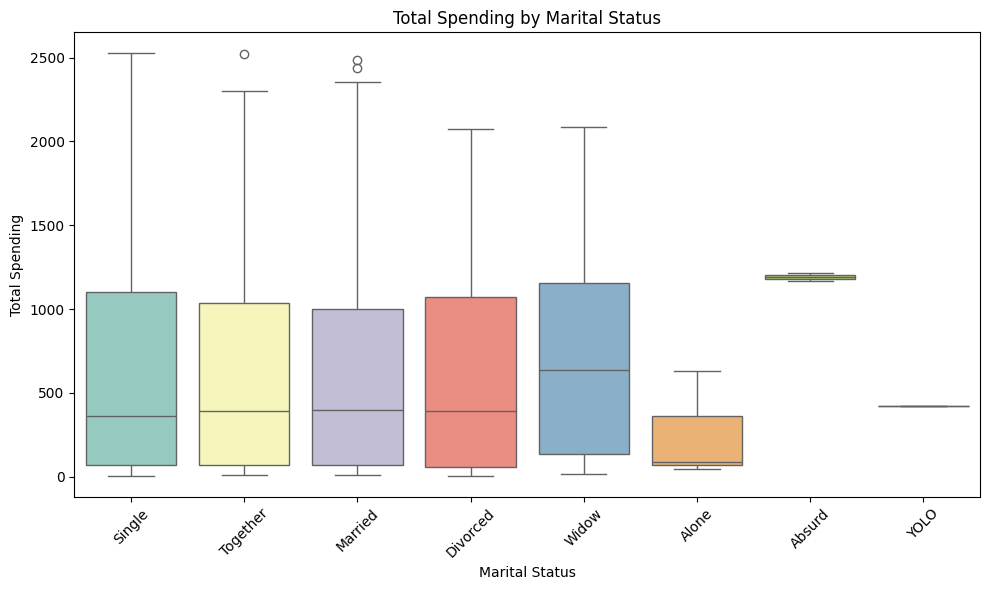

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Marital_Status', y='TotalSpending', palette='Set3')
plt.title('Total Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Widow customers show the highest median spending, while Alone customers spend the least. Absurd and YOLO categories are invalid data with very few records

## Part 3: Customer Segmentation (Unsupervised Learning)

In [25]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['Income', 'Recency', 'TotalSpending', 'TotalPurchases', 'NumWebVisitsMonth']

X = df[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("Shape:", X_scaled.shape)

Scaling done!
Shape: (2240, 5)


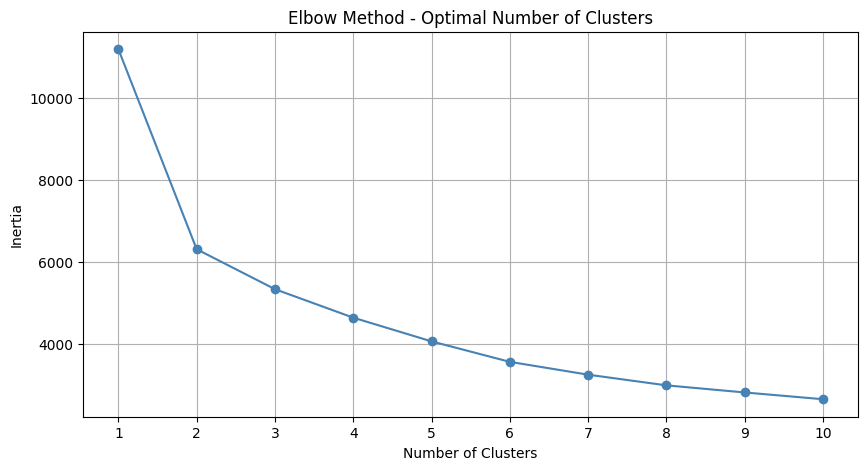

In [26]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clusters assigned!")
print(df['Cluster'].value_counts())

Clusters assigned!
Cluster
0    605
3    581
1    541
2    513
Name: count, dtype: int64


In [28]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

           Income  Recency  TotalSpending  TotalPurchases  NumWebVisitsMonth
Cluster                                                                     
0        36431.40    73.79         131.56            6.70               6.42
1        78670.51    49.82        1343.94           19.00               2.25
2        61322.40    49.50         916.97           19.13               5.88
3        36063.57    22.39         137.55            6.77               6.52


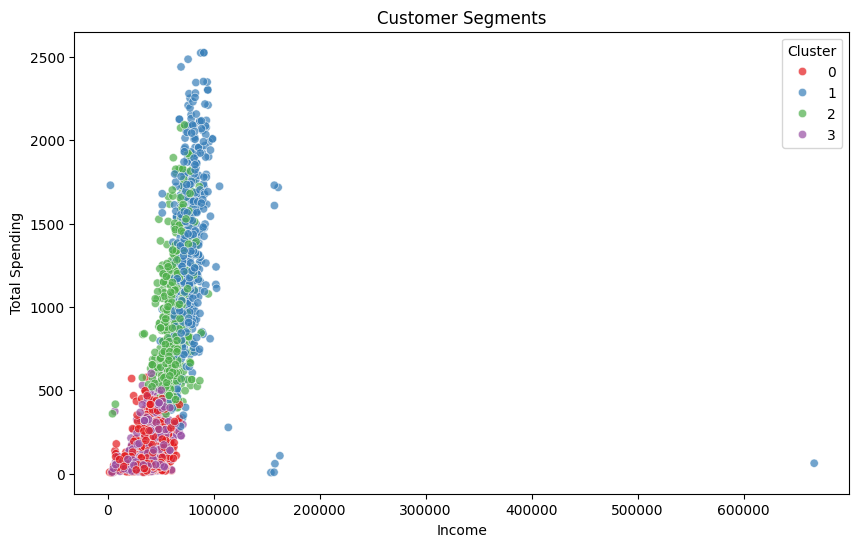

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='TotalSpending',
                hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Customer Segments')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')
plt.show()

 Part 4 — Marketing Campaign Prediction

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Select features
model_features = ['Income', 'Age', 'TotalSpending', 'TotalPurchases',
                  'TotalChildren', 'Recency', 'NumWebVisitsMonth',
                  'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5']

X = df[model_features]
y = df['Response']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1792, 12)
Test size: (448, 12)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Scaling done!")

Scaling done!


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression Results:
Accuracy:  0.8661
Precision: 0.6452
Recall:    0.2899
F1 Score:  0.4000


In [33]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")

Decision Tree Results:
Accuracy:  0.7969
Precision: 0.3333
Recall:    0.3188
F1 Score:  0.3259


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")

Random Forest Results:
Accuracy:  0.8616
Precision: 0.5946
Recall:    0.3188
F1 Score:  0.4151


In [35]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [0.8661, 0.7969, 0.8616],
    'Precision': [0.6452, 0.3333, 0.5946],
    'Recall':    [0.2899, 0.3188, 0.3188],
    'F1 Score':  [0.4000, 0.3259, 0.4151]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8661     0.6452  0.2899    0.4000
1        Decision Tree    0.7969     0.3333  0.3188    0.3259
2        Random Forest    0.8616     0.5946  0.3188    0.4151


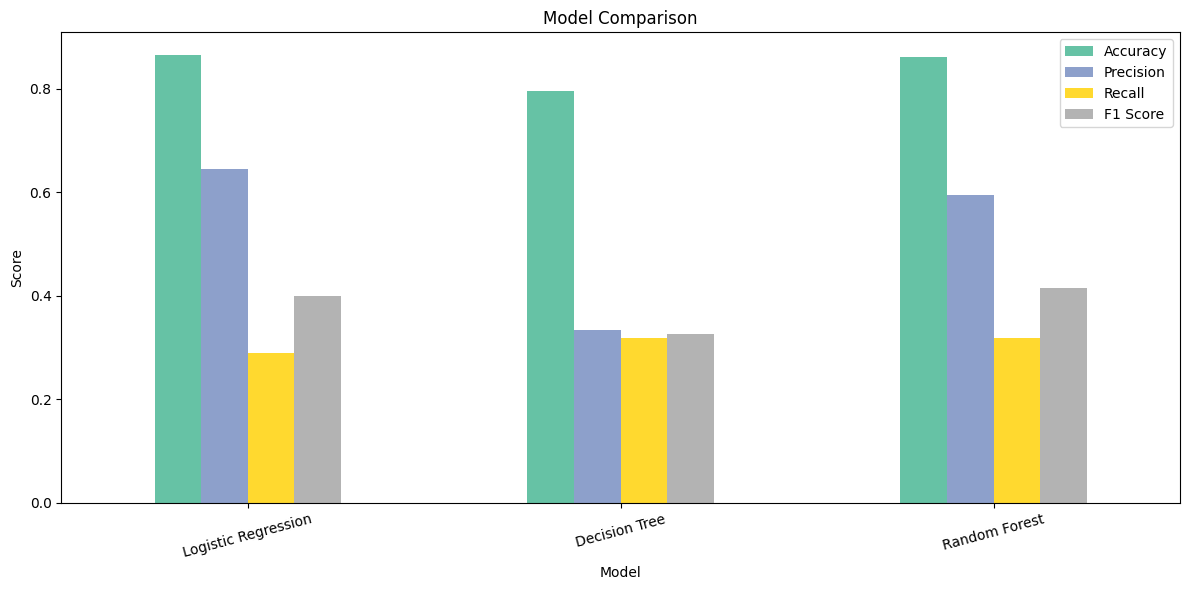

In [36]:
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Part 5: Business Insights & Recommendations

## Part 5: Business Insights and Recommendations

### Customer Segmentation Insights

- **Most Valuable Segment:** Cluster 1 — High Income, High Spending. These customers generate the most revenue and should receive premium offers.
- **Needs Attention:** Cluster 0 — Low Income, Low Spending, high Recency. These customers are becoming inactive and need re-engagement campaigns.

### Marketing Campaign Insights

- Customers who accepted previous campaigns (AcceptedCmp1-5) are more likely to accept future ones.
- High-income customers with high total spending are more responsive to campaigns.

### Recommendations

1. Focus premium offers and loyalty programs on Cluster 1 (High-Value customers).
2. Re-engage Cluster 0 customers using targeted discounts before they become fully inactive.
3. Prioritize campaign targeting for customers who accepted previous campaigns — they are the most likely to respond.